# Lab 3 — GAN-based augmentation

Conditional DCGAN with BCE + AdamW + EMA + best-by-DINOv2-cosine checkpoint
selection on DermaMNIST 28×28. Synthetics augment imbalanced train sets;
a small CNN from scratch measures whether augmentation moves the needle at 1:50
and ~1:8.

## §1 Setup

In [2]:
# §1.1 — imports
from pathlib import Path
import csv
import json
import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torchvision.utils import make_grid, save_image

from medmnist import DermaMNIST, INFO

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("torch", torch.__version__, "cuda", torch.cuda.is_available())
print("medmnist labels:", INFO['dermamnist']['label'])

/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.6.0+cu124 cuda True
medmnist labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}


In [3]:
# §1.2 — device-check
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"cuda: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("mps")
else:
    DEVICE = torch.device('cpu')
    print("cpu (GAN training will assert in §5; eval-only sections work)")
DEVICE

cuda: Tesla T4


device(type='cuda')

In [4]:
# §1.3 — seed + paths
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

LAB_ROOT = Path('.')                            # notebook runs from lab3-gan-augmentation/
DATA_DIR = LAB_ROOT / 'data'
GAN_DIR = LAB_ROOT / 'gan'
SAMPLES_DIR = GAN_DIR / 'samples'
SYNTH_DIR = LAB_ROOT / 'synth'
DINOV2_CACHE_DIR = LAB_ROOT / 'dinov2_cache'
SPLITS_CACHE = LAB_ROOT / 'splits_cache.pt'

for d in [DATA_DIR, GAN_DIR, SAMPLES_DIR, SYNTH_DIR, DINOV2_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("paths ready:", [str(p) for p in [DATA_DIR, GAN_DIR, SYNTH_DIR, DINOV2_CACHE_DIR]])

paths ready: ['data', 'gan', 'synth', 'dinov2_cache']


## §2 Data — DermaMNIST, binarize, two imbalance variants

In [5]:
# §2.1 — DermaMNIST download + binarize to mel vs not-mel
train_raw = DermaMNIST(split='train', download=True, size=28, root=str(DATA_DIR))
val_raw   = DermaMNIST(split='val',   download=True, size=28, root=str(DATA_DIR))
test_raw  = DermaMNIST(split='test',  download=True, size=28, root=str(DATA_DIR))

mel_idx = next(int(k) for k, v in INFO['dermamnist']['label'].items() if v == 'melanoma')
print(f"melanoma class index in raw labels: {mel_idx}")

def to_binary(raw):
    X = torch.from_numpy(raw.imgs).permute(0, 3, 1, 2).float() / 255.0
    X = X * 2 - 1                              # GAN expects [-1, 1]
    y = (torch.from_numpy(raw.labels).flatten() == mel_idx).long()
    return X, y

X_tr_full, y_tr_full = to_binary(train_raw)
X_va, y_va = to_binary(val_raw)
X_te, y_te = to_binary(test_raw)

print(f"train: {X_tr_full.shape}, mel={int(y_tr_full.sum())}, not-mel={int((1-y_tr_full).sum())}")
print(f"val:   {X_va.shape}, mel={int(y_va.sum())}, not-mel={int((1-y_va).sum())}")
print(f"test:  {X_te.shape}, mel={int(y_te.sum())}, not-mel={int((1-y_te).sum())}")
assert X_tr_full.shape == (7007, 3, 28, 28)
assert X_va.shape  == (1003, 3, 28, 28)
assert X_te.shape  == (2005, 3, 28, 28)
assert X_tr_full.min().item() >= -1.0 - 1e-6 and X_tr_full.max().item() <= 1.0 + 1e-6

  0%|          | 0.00/19.7M [00:00<?, ?B/s]

  0%|          | 32.8k/19.7M [00:00<01:11, 275kB/s]

  0%|          | 65.5k/19.7M [00:00<01:12, 273kB/s]

  0%|          | 98.3k/19.7M [00:00<01:12, 273kB/s]

  1%|          | 229k/19.7M [00:00<00:32, 594kB/s] 

...

 62%|██████▏   | 12.2M/19.7M [00:01<00:00, 17.8MB/s]

 76%|███████▋  | 15.0M/19.7M [00:01<00:00, 19.6MB/s]

 91%|█████████▏| 18.0M/19.7M [00:01<00:00, 21.2MB/s]

100%|██████████| 19.7M/19.7M [00:01<00:00, 12.5MB/s]

melanoma class index in raw labels: 4
train: torch.Size([7007, 3, 28, 28]), mel=779, not-mel=6228
val:   torch.Size([1003, 3, 28, 28]), mel=111, not-mel=892
test:  torch.Size([2005, 3, 28, 28]), mel=223, not-mel=1782


In [6]:
# §2.2 — natural ~1:8 variant (use binarized train as-is)
X_tr_nat, y_tr_nat = X_tr_full.clone(), y_tr_full.clone()
n_neg_nat = int((y_tr_nat == 0).sum())
n_pos_nat = int((y_tr_nat == 1).sum())
print(f"natural train: mel={n_pos_nat}, not-mel={n_neg_nat}, ratio = 1:{n_neg_nat / n_pos_nat:.2f}")

natural train: mel=779, not-mel=6228, ratio = 1:7.99


In [7]:
# §2.3 — artificial 1:50 variant (subsample mel from natural train)
rng = np.random.default_rng(SEED)
neg_idx = np.where(y_tr_full.numpy() == 0)[0]
pos_idx_full = np.where(y_tr_full.numpy() == 1)[0]
n_pos_target = len(neg_idx) // 50          # e.g. 6228 // 50 = 124
pos_idx_sub = rng.choice(pos_idx_full, size=n_pos_target, replace=False)
keep_idx = np.concatenate([neg_idx, pos_idx_sub])
keep_idx.sort()

X_tr_50 = X_tr_full[keep_idx]
y_tr_50 = y_tr_full[keep_idx]
n_neg_50 = int((y_tr_50 == 0).sum())
n_pos_50 = int((y_tr_50 == 1).sum())
print(f"1:50 train:    mel={n_pos_50}, not-mel={n_neg_50}, ratio = 1:{n_neg_50 / n_pos_50:.2f}")
assert n_pos_50 == n_pos_target

1:50 train:    mel=124, not-mel=6228, ratio = 1:50.23


In [8]:
# §2.4 — cache splits to disk so §8 can defensively reload
torch.save({
    'X_tr_nat': X_tr_nat, 'y_tr_nat': y_tr_nat,
    'X_tr_50':  X_tr_50,  'y_tr_50':  y_tr_50,
    'X_va':     X_va,     'y_va':     y_va,
    'X_te':     X_te,     'y_te':     y_te,
}, SPLITS_CACHE)
print(f"wrote {SPLITS_CACHE} ({SPLITS_CACHE.stat().st_size / 1e6:.1f} MB)")

wrote splits_cache.pt (154.1 MB)


## §3 EDA

Sanity-check the DermaMNIST binary task: class balance, what real samples look like,
and three different views of the feature space (raw pixels via PCA + t-SNE + UMAP,
plus DINOv2 features for the GAN-quality reference centroid).

               not_mel  mel
train_natural     6228  779
train_1to50       6228  124
val                892  111
test              1782  223


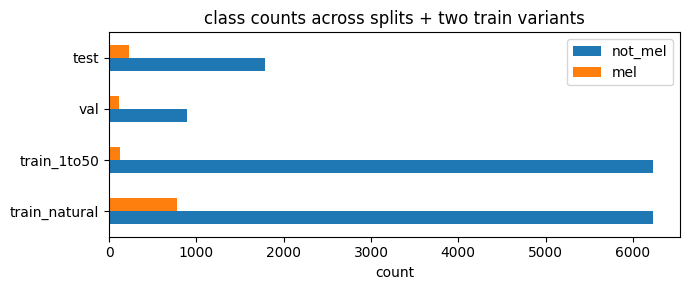

In [9]:
# §3.1 — class counts across the three splits and two train variants
counts = {
    'train_natural':  [int((y_tr_nat==0).sum()), int((y_tr_nat==1).sum())],
    'train_1to50':    [int((y_tr_50==0).sum()),  int((y_tr_50==1).sum())],
    'val':            [int((y_va==0).sum()),     int((y_va==1).sum())],
    'test':           [int((y_te==0).sum()),     int((y_te==1).sum())],
}
df_counts = pd.DataFrame(counts, index=['not_mel', 'mel']).T
print(df_counts)

fig, ax = plt.subplots(figsize=(7, 3))
df_counts.plot(kind='barh', stacked=False, ax=ax)
ax.set_title("class counts across splits + two train variants")
ax.set_xlabel("count")
plt.tight_layout(); plt.show()

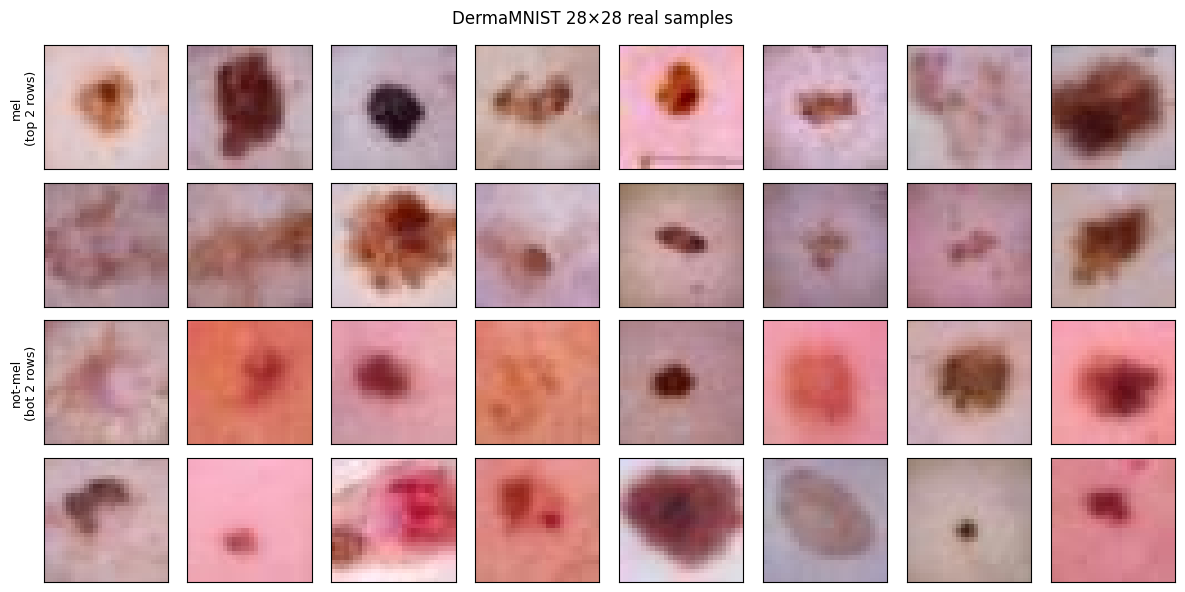

In [10]:
# §3.2 — visual: 16 mel + 16 not-mel from natural train
def to_display(x):
    """[-1,1] tensor → [0,1] for matplotlib"""
    return ((x + 1) / 2).clamp(0, 1)

mel_pos_idx = np.where(y_tr_nat.numpy() == 1)[0][:16]
not_mel_idx = np.where(y_tr_nat.numpy() == 0)[0][:16]

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, idx in zip(axes[:2].flat, mel_pos_idx):
    ax.imshow(to_display(X_tr_nat[idx]).permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([])
for ax, idx in zip(axes[2:].flat, not_mel_idx):
    ax.imshow(to_display(X_tr_nat[idx]).permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("mel\n(top 2 rows)", fontsize=9)
axes[2, 0].set_ylabel("not-mel\n(bot 2 rows)", fontsize=9)
plt.suptitle("DermaMNIST 28×28 real samples")
plt.tight_layout(); plt.show()

projecting (1000, 2352) (balanced 500 mel + 500 not-mel)…


/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


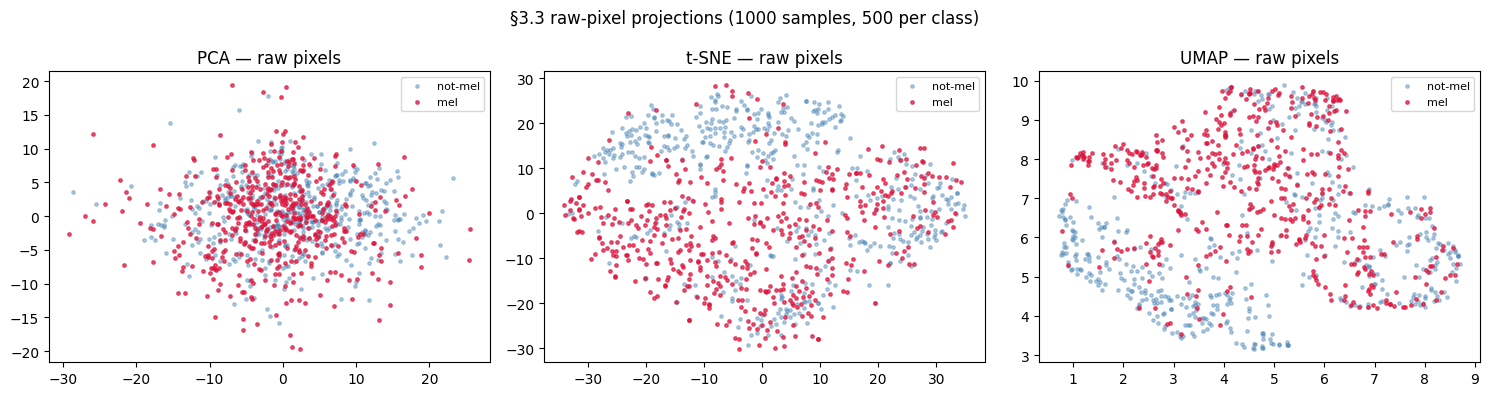

In [11]:
# §3.3 — PCA + t-SNE + UMAP on flattened pixels (natural train, balanced 1000-sample subset)
rng_eda = np.random.default_rng(SEED)
n_per_class = 500
pos_pool = np.where(y_tr_nat.numpy() == 1)[0]
neg_pool = np.where(y_tr_nat.numpy() == 0)[0]
pos_sub = rng_eda.choice(pos_pool, size=min(n_per_class, len(pos_pool)), replace=False)
neg_sub = rng_eda.choice(neg_pool, size=n_per_class, replace=False)
idx_sub = np.concatenate([pos_sub, neg_sub])
X_flat = X_tr_nat[idx_sub].reshape(len(idx_sub), -1).numpy()
y_sub = y_tr_nat[idx_sub].numpy()

print(f"projecting {X_flat.shape} (balanced {len(pos_sub)} mel + {len(neg_sub)} not-mel)…")

pca = PCA(n_components=2, random_state=SEED).fit_transform(X_flat)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init='pca',
            learning_rate='auto').fit_transform(X_flat)
ump = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15,
                min_dist=0.1).fit_transform(X_flat)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, emb, title in zip(axes, [pca, tsne, ump], ['PCA', 't-SNE', 'UMAP']):
    ax.scatter(emb[y_sub == 0, 0], emb[y_sub == 0, 1], s=6, alpha=0.4,
               c='steelblue', label='not-mel')
    ax.scatter(emb[y_sub == 1, 0], emb[y_sub == 1, 1], s=6, alpha=0.7,
               c='crimson', label='mel')
    ax.set_title(f"{title} — raw pixels")
    ax.legend(loc='best', fontsize=8)
plt.suptitle("§3.3 raw-pixel projections (1000 samples, 500 per class)")
plt.tight_layout(); plt.show()

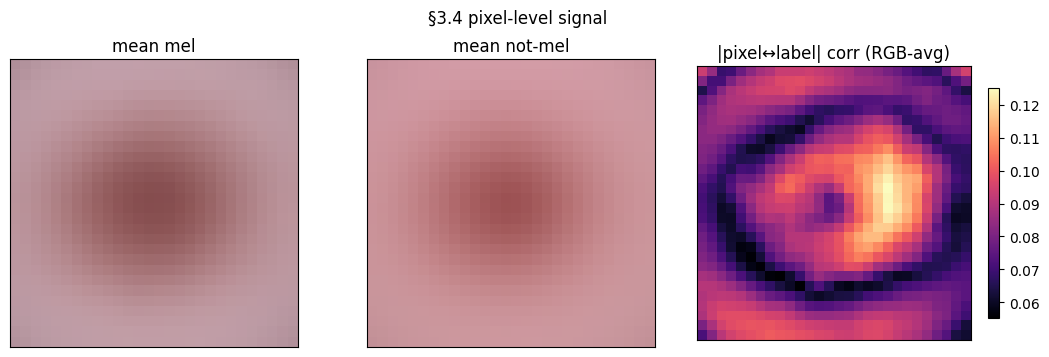

max abs pixel-corr: 0.1252  (raw pixels carry little label signal — DINOv2 §3.5 will be stronger)


In [12]:
# §3.4 — mean-image and pixel-corr-with-label per class
mean_mel    = X_tr_nat[y_tr_nat == 1].mean(dim=0)           # (3, 28, 28)
mean_notmel = X_tr_nat[y_tr_nat == 0].mean(dim=0)
diff = (mean_mel - mean_notmel).abs().mean(dim=0)            # (28, 28), abs-diff intensity

# pixel-wise point-biserial correlation w/ label, averaged over RGB
X_flat_all = X_tr_nat.reshape(len(X_tr_nat), -1).numpy()     # (N, 3*28*28)
y_arr = y_tr_nat.numpy().astype(float)
y_centered = y_arr - y_arr.mean()
X_centered = X_flat_all - X_flat_all.mean(axis=0, keepdims=True)
num = (X_centered * y_centered[:, None]).sum(axis=0)
den = np.sqrt((X_centered ** 2).sum(axis=0) * (y_centered ** 2).sum())
corr = num / (den + 1e-12)
corr_map = np.abs(corr).reshape(3, 28, 28).mean(axis=0)      # (28, 28)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
axes[0].imshow(to_display(mean_mel).permute(1, 2, 0).numpy());     axes[0].set_title("mean mel")
axes[1].imshow(to_display(mean_notmel).permute(1, 2, 0).numpy()); axes[1].set_title("mean not-mel")
im = axes[2].imshow(corr_map, cmap='magma')
axes[2].set_title("|pixel↔label| corr (RGB-avg)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.suptitle("§3.4 pixel-level signal")
plt.tight_layout(); plt.show()

print(f"max abs pixel-corr: {corr_map.max():.4f}  (raw pixels carry little label signal — DINOv2 §3.5 will be stronger)")

In [13]:
# §3.5 — DINOv2 ViT-B/14 features + real-mel centroid (re-used by §5 logging + §6.3 overlay)
DINOV2_CACHE = DINOV2_CACHE_DIR / 'train_real.npz'

print("loading DINOv2 ViT-B/14 from torch.hub (~350 MB first time)…")
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14').to(DEVICE)
dinov2.train(False)                                         # workspace convention

def dinov2_extract(x_neg1_to_pos1, batch=64):
    """x: (N, 3, 28, 28) in [-1, 1] → (N, 768) features"""
    feats = []
    with torch.no_grad():
        for i in range(0, len(x_neg1_to_pos1), batch):
            xb = x_neg1_to_pos1[i:i+batch].to(DEVICE)
            xb = (xb + 1) / 2                               # [0, 1]
            imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
            imagenet_std  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)
            xb = (xb - imagenet_mean) / imagenet_std
            xb = F.interpolate(xb, size=(224, 224), mode='bilinear', align_corners=False)
            f = dinov2(xb)                                  # (B, 768)
            feats.append(f.cpu())
    return torch.cat(feats, dim=0)

if DINOV2_CACHE.exists():
    cache = np.load(DINOV2_CACHE)
    embeds_train = torch.from_numpy(cache['embeds'])
    labels_train = torch.from_numpy(cache['labels'])
    print(f"loaded cached DINOv2 features: {embeds_train.shape}")
else:
    print(f"extracting DINOv2 features for {len(X_tr_nat)} natural-train images…")
    embeds_train = dinov2_extract(X_tr_nat)
    labels_train = y_tr_nat.clone()
    np.savez(DINOV2_CACHE, embeds=embeds_train.numpy(), labels=labels_train.numpy())
    print(f"saved DINOv2 features: {embeds_train.shape} → {DINOV2_CACHE}")

# real-mel centroid (used in §5 per-epoch cosine and §6.3 overlay)
real_mel_centroid = embeds_train[labels_train == 1].mean(dim=0)
real_mel_centroid = real_mel_centroid / (real_mel_centroid.norm() + 1e-12)
real_mel_centroid = real_mel_centroid.to(DEVICE)
print(f"real-mel centroid: shape={tuple(real_mel_centroid.shape)}, norm={real_mel_centroid.norm():.4f}")

loading DINOv2 ViT-B/14 from torch.hub (~350 MB first time)…


Using cache found in /home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main
/home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


extracting DINOv2 features for 7007 natural-train images…


saved DINOv2 features: torch.Size([7007, 768]) → dinov2_cache/train_real.npz
real-mel centroid: shape=(768,), norm=1.0000


## §4 Generator + Discriminator

Vanilla conditional DCGAN. Label conditioning: G concatenates a label embedding
with the latent; D concatenates a 28×28 broadcast embedding as a 4th input channel.

In [14]:
# §4.1 — Generator (~454k params)
class Generator(nn.Module):
    def __init__(self, z_dim=100, n_classes=2, embed_dim=10):
        super().__init__()
        self.z_dim = z_dim
        self.label_embed = nn.Embedding(n_classes, embed_dim)
        self.fc = nn.Sequential(
            nn.Linear(z_dim + embed_dim, 64 * 7 * 7),
            nn.BatchNorm1d(64 * 7 * 7),
            nn.ReLU(True),
        )
        self.up = nn.Sequential(
            nn.ConvTranspose2d(64, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),   # 7→14
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),   # 14→28
            nn.Conv2d(32, 3, 3, 1, 1), nn.Tanh(),
        )

    def forward(self, z, y):
        h = torch.cat([z, self.label_embed(y)], dim=1)
        return self.up(self.fc(h).view(-1, 64, 7, 7))

G_check = Generator()
print(f"G params: {sum(p.numel() for p in G_check.parameters()):,}")

G params: 453,847


In [15]:
# §4.2 — Discriminator (~433k params)
class Discriminator(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, 28 * 28)
        self.net = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),                              nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128),       nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256),      nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 1),
        )

    def forward(self, x, y):
        y_chan = self.label_embed(y).view(-1, 1, 28, 28)
        return self.net(torch.cat([x, y_chan], dim=1))

D_check = Discriminator()
print(f"D params: {sum(p.numel() for p in D_check.parameters()):,}")

D params: 433,121


In [16]:
# §4.3 — forward sanity tests
G_sanity = Generator().to(DEVICE)
D_sanity = Discriminator().to(DEVICE)

z_sanity = torch.randn(4, 100, device=DEVICE)
y_sanity = torch.tensor([0, 1, 0, 1], device=DEVICE)

with torch.no_grad():
    x_sanity = G_sanity(z_sanity, y_sanity)
    d_sanity = D_sanity(x_sanity, y_sanity)

print(f"G out: {tuple(x_sanity.shape)}, min={x_sanity.min():.3f}, max={x_sanity.max():.3f}")
print(f"D out: {tuple(d_sanity.shape)}")
assert x_sanity.shape == (4, 3, 28, 28)
assert d_sanity.shape == (4, 1)
assert x_sanity.min() >= -1.0 - 1e-5 and x_sanity.max() <= 1.0 + 1e-5
del G_sanity, D_sanity, z_sanity, y_sanity, x_sanity, d_sanity
print("sanity OK; using local *_sanity names so we don't shadow §8 test-split globals")

G out: (4, 3, 28, 28), min=-0.892, max=0.888
D out: (4, 1)
sanity OK; using local *_sanity names so we don't shadow §8 test-split globals


## §5 GAN training

Vanilla BCE + AdamW + EMA-G + class-balanced D batches. 200 epochs ≈ 10 min on T4.
Per-epoch logging to CSV; snapshots every 10 epochs; **best checkpoint chosen by
DINOv2 cosine similarity** to the real-mel centroid (§3.5).

In [17]:
# §5.1 — EMA shadow + class-balanced sampler helper
@torch.no_grad()
def ema_update(ema_model, model, decay=0.999):
    for p_ema, p in zip(ema_model.parameters(), model.parameters()):
        p_ema.data.mul_(decay).add_(p.data, alpha=1 - decay)
    for b_ema, b in zip(ema_model.buffers(), model.buffers()):
        b_ema.data.copy_(b.data)

def class_balanced_loader(X, y, batch_size=128):
    """WeightedRandomSampler so every batch is ~50% mel even at 1:50."""
    classes = torch.unique(y)
    counts = torch.tensor([(y == c).sum().item() for c in classes])
    weight_per_class = 1.0 / counts.float()
    sample_weights = weight_per_class[y]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(y), replacement=True)
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=0,
                      pin_memory=True, drop_last=True)

print("§5.1 helpers defined")

§5.1 helpers defined


In [51]:
# §5.2 — train loop (definition; §5.6 actually calls it)
def train_gan(X_train, y_train, *, epochs=200, batch_size=128, z_dim=100,
              lr_g=2e-4, lr_d=2e-4, betas=(0.5, 0.999), weight_decay=1e-5,
              ema_decay=0.999, snapshot_every=10, log_path=None, samples_dir=None):
    assert DEVICE.type == 'cuda', "GAN training requires CUDA (T4 VM)"
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    np.random.seed(SEED)

    G = Generator(z_dim=z_dim).to(DEVICE)
    D = Discriminator().to(DEVICE)
    G_ema = Generator(z_dim=z_dim).to(DEVICE)
    G_ema.load_state_dict(G.state_dict())
    for p in G_ema.parameters():
        p.requires_grad_(False)

    opt_G = torch.optim.AdamW(G.parameters(), lr=lr_g, betas=betas, weight_decay=weight_decay)
    opt_D = torch.optim.AdamW(D.parameters(), lr=lr_d, betas=betas, weight_decay=weight_decay)

    loader = class_balanced_loader(X_train, y_train, batch_size=batch_size)
    bce = nn.BCEWithLogitsLoss()

    snapshots = []                              # [(epoch, G_sd, G_ema_sd, D_sd)]
    log_rows = []

    # fixed sample noise for grid PNGs (8×8 = 32 mel + 32 not-mel)
    fixed_z = torch.randn(64, z_dim, device=DEVICE)
    fixed_y = torch.cat([torch.ones(32), torch.zeros(32)]).long().to(DEVICE)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        G.train(); D.train()
        g_losses, d_losses, d_real_correct, d_fake_correct, n_seen = 0, 0, 0, 0, 0
        for x_real, y_real in loader:
            x_real = x_real.to(DEVICE); y_real = y_real.to(DEVICE)
            bs = x_real.size(0)
            real_labels = torch.ones(bs, 1, device=DEVICE)
            fake_labels = torch.zeros(bs, 1, device=DEVICE)

            # ---- D step ----
            opt_D.zero_grad(set_to_none=True)
            d_real = D(x_real, y_real)
            loss_d_real = bce(d_real, real_labels)

            z = torch.randn(bs, z_dim, device=DEVICE)
            y_fake = torch.randint(0, 2, (bs,), device=DEVICE)
            x_fake = G(z, y_fake).detach()
            d_fake = D(x_fake, y_fake)
            loss_d_fake = bce(d_fake, fake_labels)
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward(); opt_D.step()

            # ---- G step ----
            opt_G.zero_grad(set_to_none=True)
            z = torch.randn(bs, z_dim, device=DEVICE)
            y_fake = torch.randint(0, 2, (bs,), device=DEVICE)
            x_fake = G(z, y_fake)
            d_fake_for_g = D(x_fake, y_fake)
            loss_g = bce(d_fake_for_g, real_labels)
            loss_g.backward(); opt_G.step()

            ema_update(G_ema, G, decay=ema_decay)

            g_losses += loss_g.item() * bs
            d_losses += loss_d.item() * bs
            d_real_correct += (torch.sigmoid(d_real) > 0.5).sum().item()
            d_fake_correct += (torch.sigmoid(d_fake) < 0.5).sum().item()
            n_seen += bs

        # ---- per-epoch logging ----
        G_ema.train(False)
        with torch.no_grad():
            z_eval = torch.randn(256, z_dim, device=DEVICE)
            y_eval = torch.ones(256, dtype=torch.long, device=DEVICE)         # mel
            x_eval = G_ema(z_eval, y_eval)
            feats_eval = dinov2_extract(x_eval.cpu())                          # (256, 768)
            feats_eval = feats_eval / (feats_eval.norm(dim=1, keepdim=True) + 1e-12)
            cos = (feats_eval.to(DEVICE) @ real_mel_centroid).mean().item()

        row = {
            'epoch': epoch,
            'G_loss': g_losses / n_seen,
            'D_loss': d_losses / n_seen,
            'D_real_acc': d_real_correct / n_seen,
            'D_fake_acc': d_fake_correct / n_seen,
            'dinov2_cos': cos,
            'sec': time.time() - t0,
        }
        log_rows.append(row)

        # ---- snapshot (every snapshot_every) ----
        if epoch % snapshot_every == 0 or epoch == epochs:
            # store state_dicts on CPU — 200 snapshots × 3 sd × ~3 MB = ~1.8 GB; GPU-side would
            # squeeze training tightly on a 16 GB T4.
            snapshots.append((
                epoch,
                {k: v.detach().cpu().clone() for k, v in G.state_dict().items()},
                {k: v.detach().cpu().clone() for k, v in G_ema.state_dict().items()},
                {k: v.detach().cpu().clone() for k, v in D.state_dict().items()},
            ))
        # ---- sample-grid PNG (decoupled from snapshots: always every 10 epochs for inspection) ----
        if epoch % 10 == 0 or epoch == epochs:
            with torch.no_grad():
                grid_imgs = G_ema(fixed_z, fixed_y)
                grid_imgs = (grid_imgs + 1) / 2
                grid = make_grid(grid_imgs, nrow=8)
                if samples_dir is not None:
                    save_image(grid, samples_dir / f"epoch_{epoch:03d}.png")
            print(f"  epoch {epoch:3d} | G {row['G_loss']:.3f} D {row['D_loss']:.3f} "
                  f"| D_real {row['D_real_acc']:.2f} D_fake {row['D_fake_acc']:.2f} "
                  f"| cos {cos:.4f} | {row['sec']:.1f}s")

    if log_path is not None:
        pd.DataFrame(log_rows).to_csv(log_path, index=False)

    return G, G_ema, D, snapshots, log_rows

print("§5.2 train_gan defined")

§5.2 train_gan defined


In [52]:
# §5.5 — pick the best snapshot by argmax(discriminative margin), save ckpts (tie-break: latest)
#
# Selection metric: for each snapshot's EMA-G, generate 256 mel samples, compute their DINOv2
# embeddings, then:
#    margin = mean_cos(synth_mel, real_mel_centroid) − mean_cos(synth_mel, real_notmel_centroid)
# Pick the snapshot that maximizes margin — this rewards G that produces synth-mel which is
# both close to real-mel AND far from real-not-mel, rather than just close to real-mel (which
# can be satisfied by samples in the overlap zone, where the GAN's conditioning is weak).
def save_best_ckpt(snapshots, log_rows, gan_dir, *, metric='margin',
                   dinov2_extract_fn=None, real_mel_centroid=None,
                   real_notmel_centroid=None, n_eval=256, z_dim=100):
    if metric == 'cos':
        df_log = pd.DataFrame(log_rows)
        snap_epochs = [s[0] for s in snapshots]
        scores = df_log.set_index('epoch').loc[snap_epochs]['dinov2_cos'].values
        per_snap = None
    elif metric == 'margin':
        assert dinov2_extract_fn is not None and real_mel_centroid is not None and real_notmel_centroid is not None
        per_snap = []
        for epoch, G_sd, G_ema_sd, D_sd in snapshots:
            G_eval = Generator(z_dim=z_dim).to(DEVICE)
            # snapshot state_dicts may be on CPU (large-snapshot mode) — move to current device
            G_eval.load_state_dict({k: v.to(DEVICE) for k, v in G_ema_sd.items()})
            G_eval.train(False)
            with torch.no_grad():
                z = torch.randn(n_eval, z_dim, device=DEVICE)
                y = torch.ones(n_eval, dtype=torch.long, device=DEVICE)
                synth = G_eval(z, y).cpu()
            feats = dinov2_extract_fn(synth)
            feats = feats / (feats.norm(dim=1, keepdim=True) + 1e-12)
            cm = (feats.to(DEVICE) @ real_mel_centroid).mean().item()
            cn = (feats.to(DEVICE) @ real_notmel_centroid).mean().item()
            m = cm - cn
            per_snap.append({'epoch': epoch, 'cos_mel': cm, 'cos_notmel': cn, 'margin': m})
            print(f"  snap epoch {epoch:3d}: cos_mel={cm:.4f}  cos_notmel={cn:.4f}  margin={m:+.4f}")
        scores = np.array([s['margin'] for s in per_snap])
    else:
        raise ValueError(f"unknown metric: {metric}")
    max_score = scores.max()
    best_local = int(np.where(scores == max_score)[0][-1])
    best_epoch, G_sd, G_ema_sd, D_sd = snapshots[best_local]
    torch.save(G_sd,     gan_dir / 'ckpt_G.pt')
    torch.save(G_ema_sd, gan_dir / 'ckpt_G_ema.pt')
    torch.save(D_sd,     gan_dir / 'ckpt_D.pt')
    # Persist per-snapshot data so §6.3 can plot the margin trajectory
    if per_snap is not None:
        margin_log_path = gan_dir / 'margin_log.csv'
        pd.DataFrame(per_snap).to_csv(margin_log_path, index=False)
        print(f"  wrote per-snapshot margin log → {margin_log_path}")
    print(f"\nbest ckpt by {metric}: epoch {best_epoch} (score={max_score:+.4f}) "
          f"→ ckpt_G.pt / ckpt_G_ema.pt / ckpt_D.pt")
    return best_epoch, max_score

print("§5.5 save_best_ckpt defined (metric='margin' default; supports 'cos' fallback)")

§5.5 save_best_ckpt defined (metric='margin' default; supports 'cos' fallback)


In [53]:
# §5.6 — execute training on the natural ~1:8 train split
# Rationale: more mel samples = better GAN data. The 1:50 train has only 124 mel images,
# too few for cDCGAN. The trained G_ema then generates synth-mel for both 1:50 and 1:8
# downstream conditions.

print(f"training cDCGAN on natural train: mel={int(y_tr_nat.sum())}, not-mel={int((1-y_tr_nat).sum())}")
G_final, G_ema_final, D_final, snapshots, log_rows = train_gan(
    X_tr_nat, y_tr_nat,
    epochs=200, batch_size=128, z_dim=100,
    lr_g=2e-4, lr_d=2e-4, betas=(0.5, 0.999), weight_decay=1e-5,
    ema_decay=0.999, snapshot_every=1,    # snapshot every epoch → 200 snapshots for fine-grained margin selection
    log_path=GAN_DIR / 'train_log.csv',
    samples_dir=SAMPLES_DIR,
)
# real_notmel_centroid needed for margin metric; compute here so this cell is self-contained
# on a top-to-bottom rerun.
_real_notmel_centroid = embeds_train[labels_train == 0].mean(dim=0)
_real_notmel_centroid = _real_notmel_centroid / (_real_notmel_centroid.norm() + 1e-12)
_real_notmel_centroid = _real_notmel_centroid.to(DEVICE)
best_epoch, best_margin = save_best_ckpt(
    snapshots, log_rows, GAN_DIR,
    metric='margin',
    dinov2_extract_fn=dinov2_extract,
    real_mel_centroid=real_mel_centroid,
    real_notmel_centroid=_real_notmel_centroid,
)

training cDCGAN on natural train: mel=779, not-mel=6228


  epoch  10 | G 0.786 D 1.289 | D_real 0.74 D_fake 0.76 | cos 0.4139 | 5.3s


  epoch  20 | G 0.834 D 1.261 | D_real 0.74 D_fake 0.76 | cos 0.4949 | 5.7s


  epoch  30 | G 0.938 D 1.156 | D_real 0.82 D_fake 0.83 | cos 0.6450 | 5.9s


  epoch  40 | G 1.010 D 1.062 | D_real 0.87 D_fake 0.88 | cos 0.7766 | 6.1s


...

  snap epoch 196: cos_mel=0.7562  cos_notmel=0.7223  margin=+0.0339


  snap epoch 197: cos_mel=0.7687  cos_notmel=0.7382  margin=+0.0305


  snap epoch 198: cos_mel=0.7718  cos_notmel=0.7410  margin=+0.0308


  snap epoch 199: cos_mel=0.7667  cos_notmel=0.7341  margin=+0.0325


  snap epoch 200: cos_mel=0.7688  cos_notmel=0.7402  margin=+0.0286
  wrote per-snapshot margin log → gan/margin_log.csv

best ckpt by margin: epoch 195 (score=+0.0382) → ckpt_G.pt / ckpt_G_ema.pt / ckpt_D.pt


In [65]:
# §5.7 — val-MCC ckpt selection (the task-aligned alternative to margin selection)
#
# For each snapshot, generate a small synth pool, augment real-train, train a short CNN,
# measure val MCC. Pick the snapshot whose synth gave the best downstream val MCC.
# Cost: ~6 sec/snapshot. We sample every-5th snapshot (40 of the 200) to keep wallclock manageable.

def select_by_val_mcc(snapshots, X_train_real, y_train_real, X_val, y_val,
                      stride=5, n_synth=None, k_epochs=10, batch_size=64, z_dim=100):
    if n_synth is None:
        n_synth = int(y_train_real.sum())   # default = 100% dose
    rows = []
    sampled = snapshots[::stride] if stride > 1 else snapshots
    print(f"running val-MCC selection on {len(sampled)} snapshots "
          f"(stride={stride}, n_synth={n_synth}, k_epochs={k_epochs})…")
    for epoch, G_sd, G_ema_sd, D_sd in sampled:
        # 1. load G_ema, generate synth pool
        G_eval = Generator(z_dim=z_dim).to(DEVICE)
        G_eval.load_state_dict({k: v.to(DEVICE) for k, v in G_ema_sd.items()})
        G_eval.train(False)
        torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
        with torch.no_grad():
            z = torch.randn(n_synth, z_dim, device=DEVICE)
            y = torch.ones(n_synth, dtype=torch.long, device=DEVICE)
            synth = G_eval(z, y).cpu()
        # 2. augment train
        X_aug = torch.cat([X_train_real, synth], dim=0)
        y_aug = torch.cat([y_train_real, torch.ones(n_synth, dtype=torch.long)], dim=0)
        # 3. quick CNN training (k_epochs, no early-stop)
        torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED); np.random.seed(SEED)
        model = build_small_cnn().to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        ce = nn.CrossEntropyLoss()
        ds = TensorDataset(X_aug, y_aug)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=False)
        for _ in range(k_epochs):
            model.train()
            for xb, yb in loader:
                xb = xb.to(DEVICE); yb = yb.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                loss = ce(model(xb), yb)
                loss.backward(); opt.step()
        # 4. val MCC
        model.train(False)
        with torch.no_grad():
            probs = torch.softmax(model(X_val.to(DEVICE)), dim=1).cpu()
        val_mcc = matthews_corrcoef(y_val.numpy(), probs.argmax(dim=1).numpy())
        rows.append({'epoch': epoch, 'val_mcc': val_mcc})
        print(f"  snap epoch {epoch:3d}: val_mcc={val_mcc:+.4f}")
    return pd.DataFrame(rows)

df_valmcc = select_by_val_mcc(snapshots, X_tr_nat, y_tr_nat, X_va, y_va,
                              stride=5, n_synth=int(y_tr_nat.sum()), k_epochs=10)
# Stride misses the margin-selected epoch — evaluate it explicitly so the two
# metrics can be compared head-to-head at the same snapshot.
if best_epoch not in df_valmcc['epoch'].values:
    extra_snap = [t for t in snapshots if t[0] == best_epoch]
    df_extra = select_by_val_mcc(extra_snap, X_tr_nat, y_tr_nat, X_va, y_va,
                                 stride=1, n_synth=int(y_tr_nat.sum()), k_epochs=10)
    df_valmcc = (pd.concat([df_valmcc, df_extra], ignore_index=True)
                   .sort_values('epoch').reset_index(drop=True))
df_valmcc.to_csv(GAN_DIR / 'valmcc_log.csv', index=False)
best_idx_vm = df_valmcc['val_mcc'].idxmax()
best_epoch_valmcc = int(df_valmcc.loc[best_idx_vm, 'epoch'])
best_valmcc = float(df_valmcc.loc[best_idx_vm, 'val_mcc'])
val_mcc_at_margin = float(df_valmcc.loc[df_valmcc['epoch'] == best_epoch, 'val_mcc'].iloc[0])
print(f"\nbest by val_mcc: epoch {best_epoch_valmcc} (val_mcc={best_valmcc:+.4f})")
print(f"best by margin:  epoch {best_epoch} (margin={best_margin:+.4f}, val_mcc={val_mcc_at_margin:+.4f})")
print(f"\n→ keeping the **margin-selected** ckpt on disk (epoch {best_epoch}); "
      f"val-MCC comparison is for §9 analysis only.")

running val-MCC selection on 40 snapshots (stride=5, n_synth=779, k_epochs=10)…


  snap epoch   1: val_mcc=+0.0896


  snap epoch   6: val_mcc=+0.2007


  snap epoch  11: val_mcc=+0.0896


  snap epoch  16: val_mcc=+0.1267


...

  snap epoch 181: val_mcc=+0.3699


  snap epoch 186: val_mcc=+0.3452


  snap epoch 191: val_mcc=+0.3626


  snap epoch 196: val_mcc=+0.4044
running val-MCC selection on 1 snapshots (stride=1, n_synth=779, k_epochs=10)…


  snap epoch 195: val_mcc=+0.3761

best by val_mcc: epoch 171 (val_mcc=+0.4044)
best by margin:  epoch 195 (margin=+0.0382, val_mcc=+0.3761)

→ keeping the **margin-selected** ckpt on disk (epoch 195); val-MCC comparison is for §9 analysis only.


## §6 GAN evaluation

Diagnostic plots from `train_log.csv` + sample-grid montage + DINOv2-cosine trajectory
+ PCA/UMAP overlay of (real_mel + real_notmel + synth_mel) DINOv2 embeddings.

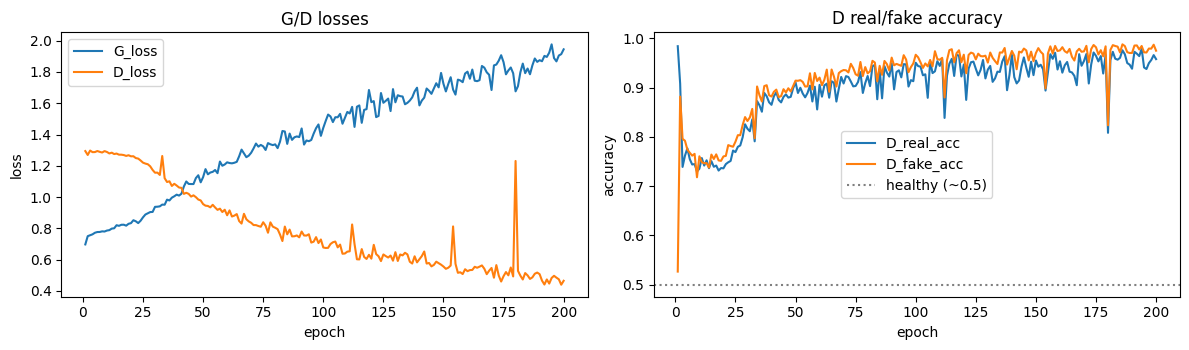

In [55]:
# §6.1 — loss + D-accuracy curves
df_log = pd.read_csv(GAN_DIR / 'train_log.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(df_log['epoch'], df_log['G_loss'], label='G_loss')
axes[0].plot(df_log['epoch'], df_log['D_loss'], label='D_loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('G/D losses')

axes[1].plot(df_log['epoch'], df_log['D_real_acc'], label='D_real_acc')
axes[1].plot(df_log['epoch'], df_log['D_fake_acc'], label='D_fake_acc')
axes[1].axhline(0.5, color='gray', linestyle=':', label='healthy (~0.5)')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('D real/fake accuracy')
plt.tight_layout(); plt.show()

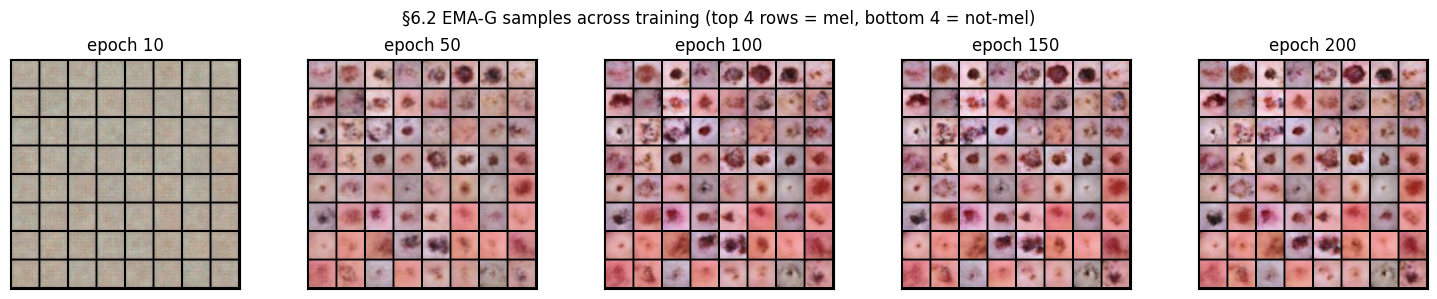

In [22]:
# §6.2 — sample grids across epochs (visual progression)
from PIL import Image
landmark_epochs = [10, 50, 100, 150, 200]
fig, axes = plt.subplots(1, len(landmark_epochs), figsize=(3 * len(landmark_epochs), 3))
for ax, ep in zip(axes, landmark_epochs):
    p = SAMPLES_DIR / f"epoch_{ep:03d}.png"
    if p.exists():
        ax.imshow(Image.open(p))
        ax.set_title(f"epoch {ep}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("§6.2 EMA-G samples across training (top 4 rows = mel, bottom 4 = not-mel)")
plt.tight_layout(); plt.show()

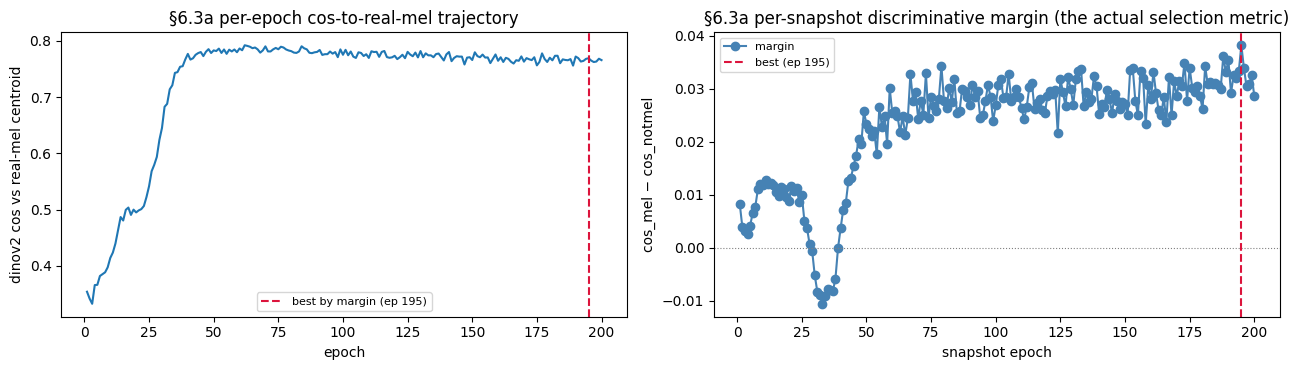

/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


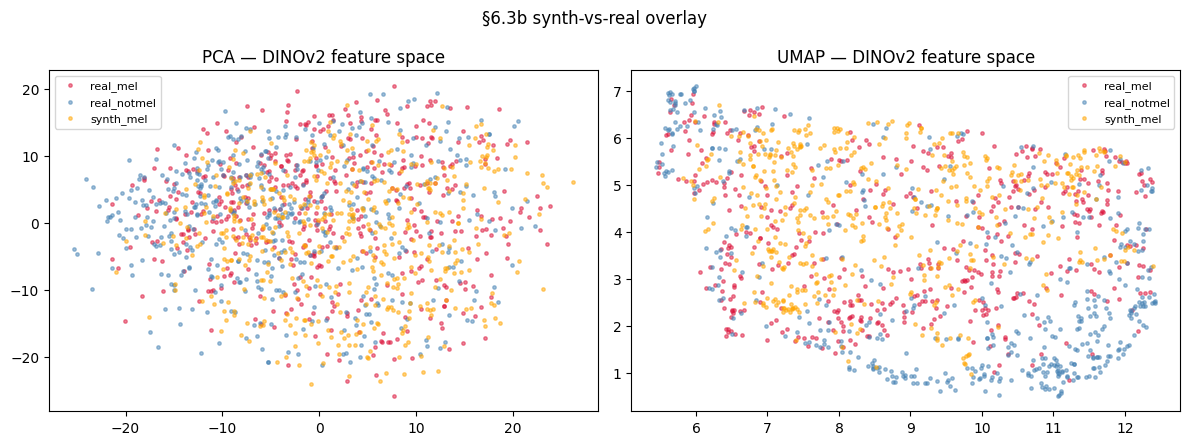

synth_mel  vs real_mel centroid:    0.7694
synth_mel  vs real_notmel centroid: 0.7363
discriminative margin (>0 = synth closer to mel): +0.0331


In [56]:
# §6.3 — DINOv2 cos trajectory + margin trajectory + synth-vs-real overlay
df_margin = pd.read_csv(GAN_DIR / 'margin_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
# §6.3a-left: per-epoch cos-to-real-mel (200 points)
axes[0].plot(df_log['epoch'], df_log['dinov2_cos'])
axes[0].axvline(best_epoch, color='crimson', linestyle='--', label=f'best by margin (ep {best_epoch})')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('dinov2 cos vs real-mel centroid')
axes[0].set_title('§6.3a per-epoch cos-to-real-mel trajectory')
axes[0].legend(fontsize=8)
# §6.3a-right: per-snapshot margin (20 points) — what selection actually optimizes
axes[1].plot(df_margin['epoch'], df_margin['margin'], 'o-', color='steelblue', label='margin')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].axvline(best_epoch, color='crimson', linestyle='--', label=f'best (ep {best_epoch})')
axes[1].set_xlabel('snapshot epoch'); axes[1].set_ylabel('cos_mel − cos_notmel')
axes[1].set_title('§6.3a per-snapshot discriminative margin (the actual selection metric)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# load best-ckpt G_ema and generate synth-mel for overlay
G_ema_best = Generator().to(DEVICE)
G_ema_best.load_state_dict(torch.load(GAN_DIR / 'ckpt_G_ema.pt', map_location=DEVICE))
G_ema_best.train(False)
with torch.no_grad():
    z_overlay = torch.randn(500, 100, device=DEVICE)
    y_overlay = torch.ones(500, dtype=torch.long, device=DEVICE)
    synth_overlay = G_ema_best(z_overlay, y_overlay).cpu()

synth_overlay_feats = dinov2_extract(synth_overlay).numpy()
real_mel_feats    = embeds_train[labels_train == 1].numpy()
real_notmel_feats = embeds_train[labels_train == 0].numpy()

# subsample for plotting
rng_o = np.random.default_rng(SEED)
real_mel_sub    = real_mel_feats[rng_o.choice(len(real_mel_feats),
                                              size=min(500, len(real_mel_feats)), replace=False)]
real_notmel_sub = real_notmel_feats[rng_o.choice(len(real_notmel_feats), size=500, replace=False)]

X_overlay = np.concatenate([real_mel_sub, real_notmel_sub, synth_overlay_feats], axis=0)
labels_overlay = (['real_mel'] * len(real_mel_sub)
                  + ['real_notmel'] * len(real_notmel_sub)
                  + ['synth_mel'] * len(synth_overlay_feats))

pca_o = PCA(n_components=2, random_state=SEED).fit_transform(X_overlay)
ump_o = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X_overlay)

colors_map = {'real_mel': 'crimson', 'real_notmel': 'steelblue', 'synth_mel': 'orange'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, emb, title in zip(axes, [pca_o, ump_o], ['PCA', 'UMAP']):
    for lbl, color in colors_map.items():
        mask = np.array(labels_overlay) == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1], s=6, alpha=0.5, c=color, label=lbl)
    ax.set_title(f"{title} — DINOv2 feature space")
    ax.legend(fontsize=8)
plt.suptitle("§6.3b synth-vs-real overlay")
plt.tight_layout(); plt.show()

# scalar summary: how close is synth_mel to real_mel centroid vs real_notmel centroid?
synth_norm = torch.from_numpy(synth_overlay_feats) / (torch.from_numpy(synth_overlay_feats).norm(dim=1, keepdim=True) + 1e-12)
real_notmel_centroid = embeds_train[labels_train == 0].mean(dim=0)
real_notmel_centroid = real_notmel_centroid / (real_notmel_centroid.norm() + 1e-12)
real_notmel_centroid = real_notmel_centroid.to(DEVICE)
cos_to_mel = (synth_norm.to(DEVICE) @ real_mel_centroid).mean().item()
cos_to_notmel = (synth_norm.to(DEVICE) @ real_notmel_centroid).mean().item()
print(f"synth_mel  vs real_mel centroid:    {cos_to_mel:.4f}")
print(f"synth_mel  vs real_notmel centroid: {cos_to_notmel:.4f}")
print(f"discriminative margin (>0 = synth closer to mel): {cos_to_mel - cos_to_notmel:+.4f}")

saved 6204 synth-mel images to synth/mel_synth.pt (58.42 MB)


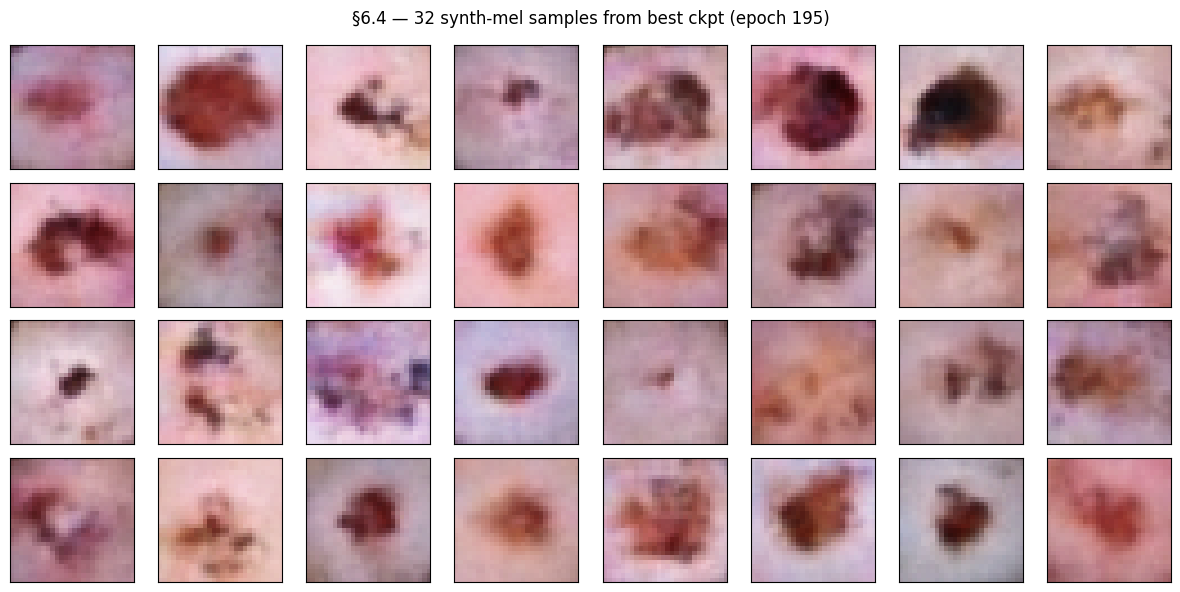

In [57]:
# §6.4 — generate one master synth-mel pool (size = max dose = 6228 − 124 = 6104 for 1:50 balanced)
# Pool covers every condition in §8 (the largest dose is "balanced at 1:50": add 6104 synth-mel
# so the combined train has ~6228 mel + 6228 not-mel).
N_POOL = int((1 - y_tr_50).sum()) - int(y_tr_50.sum()) + 100   # = 6228 - 124 + 100 = 6204 (small safety buffer)
G_ema_best.train(False)
torch.manual_seed(SEED)        # deterministic synth pool
with torch.no_grad():
    # generate in chunks to avoid spiking GPU memory
    chunk = 256
    parts = []
    for i in range(0, N_POOL, chunk):
        cur = min(chunk, N_POOL - i)
        z_chunk = torch.randn(cur, 100, device=DEVICE)
        y_chunk = torch.ones(cur, dtype=torch.long, device=DEVICE)
        parts.append(G_ema_best(z_chunk, y_chunk).cpu())
    synth_pool = torch.cat(parts, dim=0)
    y_pool = torch.ones(N_POOL, dtype=torch.long)
torch.save({'images': synth_pool, 'labels': y_pool}, SYNTH_DIR / 'mel_synth.pt')
print(f"saved {N_POOL} synth-mel images to {SYNTH_DIR / 'mel_synth.pt'} "
      f"({(SYNTH_DIR / 'mel_synth.pt').stat().st_size / 1e6:.2f} MB)")

# visual sanity: show 32 of them
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, idx in zip(axes.flat, range(32)):
    ax.imshow(to_display(synth_pool[idx]).permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"§6.4 — 32 synth-mel samples from best ckpt (epoch {best_epoch})")
plt.tight_layout(); plt.show()

## §7 Downstream CNN

Small from-scratch CNN (~68k params). `train_cnn` reseeds internally so the
sweep is reproducible across fresh kernels. `evaluate_on_test` returns the same
column schema as Lab 1/2's helper.

In [25]:
# §7.1 — small CNN (~68k params)
def build_small_cnn(num_classes=2):
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, 1, 1),  nn.BatchNorm2d(32), nn.ReLU(True),
        nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
        nn.MaxPool2d(2),                                                    # 28→14
        nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
        nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
        nn.MaxPool2d(2),                                                    # 14→7
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(64, 32), nn.ReLU(True),
        nn.Linear(32, num_classes),
    )

cnn_check = build_small_cnn()
print(f"small CNN params: {sum(p.numel() for p in cnn_check.parameters()):,}")

small CNN params: 68,098


In [44]:
# §7.2 — train_cnn (reseeds internally; early-stop on val MCC)
from sklearn.metrics import matthews_corrcoef

def _mcc(probs, y):
    return matthews_corrcoef(y.cpu().numpy(), probs.argmax(dim=1).cpu().numpy())

def train_cnn(X_train, y_train, X_val, y_val, *, epochs=30, batch_size=64,
              lr=1e-3, weight_decay=1e-4, patience=5):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    np.random.seed(SEED)
    model = build_small_cnn().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    ce = nn.CrossEntropyLoss()

    ds = TensorDataset(X_train, y_train)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0,
                        pin_memory=True, drop_last=False)

    best_val_mcc, best_epoch, best_sd, bad = -2.0, 0, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = ce(logits, yb)
            loss.backward(); opt.step()
        # val eval
        model.train(False)
        with torch.no_grad():
            probs_val = torch.softmax(model(X_val.to(DEVICE)), dim=1).cpu()
        val_mcc = _mcc(probs_val, y_val)
        if val_mcc > best_val_mcc + 1e-6:
            best_val_mcc, best_epoch, bad = val_mcc, epoch, 0
            best_sd = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_sd)
    return model, {'val_mcc_best': best_val_mcc, 'epoch_stopped': best_epoch}

print("§7.2 train_cnn defined")

§7.2 train_cnn defined


In [27]:
# §7.3 — evaluate_on_test (matches Lab 1/2 column schema)
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score

def evaluate_on_test(model, X_test, y_test):
    model.train(False)
    with torch.no_grad():
        logits = model(X_test.to(DEVICE))
        probs = torch.softmax(logits, dim=1).cpu()
    pred = probs.argmax(dim=1).numpy()
    y = y_test.numpy()
    return {
        'test_mcc':       matthews_corrcoef(y, pred),
        'test_acc':       accuracy_score(y, pred),
        'test_bal_acc':   balanced_accuracy_score(y, pred),
        'test_rec_pos':   recall_score(y, pred, pos_label=1, zero_division=0),
        'test_prec_pos':  precision_score(y, pred, pos_label=1, zero_division=0),
        'test_f1_pos':    f1_score(y, pred, pos_label=1, zero_division=0),
    }

print("§7.3 evaluate_on_test defined")

§7.3 evaluate_on_test defined


## §8 Sweep

Eight experiments: {1:50, 1:8} × {real_only, +synth_50pct, +synth_100pct, +synth_balanced}.
Synth images sliced from `mel_synth.pt` (same z's across doses → deterministic).
The "balanced" condition adds enough synth-mel so total mel ≈ total not-mel after merging.

In [58]:
# §8.1 — defensively reload splits + synth (in case earlier cells were re-run mid-sweep)
cache = torch.load(SPLITS_CACHE, weights_only=True)
X_tr_nat_r, y_tr_nat_r = cache['X_tr_nat'], cache['y_tr_nat']
X_tr_50_r,  y_tr_50_r  = cache['X_tr_50'],  cache['y_tr_50']
X_va_r, y_va_r = cache['X_va'], cache['y_va']
X_te_r, y_te_r = cache['X_te'], cache['y_te']
synth_blob = torch.load(SYNTH_DIR / 'mel_synth.pt', weights_only=True)
synth_images, synth_labels = synth_blob['images'], synth_blob['labels']
print(f"reloaded — natural mel={int(y_tr_nat_r.sum())}, 1:50 mel={int(y_tr_50_r.sum())}, "
      f"synth pool={len(synth_images)}")

reloaded — natural mel=779, 1:50 mel=124, synth pool=6204


In [62]:
# §8.2 — run 8 experiments: {1:50, 1:8} × {real_only, +synth_50pct, +synth_100pct, +synth_balanced}
def add_synth(X_real, y_real, n_synth):
    if n_synth == 0:
        return X_real.clone(), y_real.clone()
    X_syn = synth_images[:n_synth]
    y_syn = synth_labels[:n_synth]
    return torch.cat([X_real, X_syn], dim=0), torch.cat([y_real, y_syn], dim=0)

def n_real_mel(y):
    return int(y.sum())

def n_real_notmel(y):
    return int((1 - y).sum())

experiments = []
for imb_name, X_tr_imb, y_tr_imb in [('1:50', X_tr_50_r, y_tr_50_r),
                                      ('1:8',  X_tr_nat_r, y_tr_nat_r)]:
    n_mel_real = n_real_mel(y_tr_imb)
    n_notmel_real = n_real_notmel(y_tr_imb)
    # balanced: add enough synth-mel so total mel ≈ not-mel
    n_for_balance = max(n_notmel_real - n_mel_real, 0)
    for cond_name, n_syn in [('real_only',          0),
                              ('real+synth_50pct',   n_mel_real // 2),
                              ('real+synth_100pct',  n_mel_real),
                              ('real+synth_balanced', n_for_balance)]:
        experiments.append((imb_name, cond_name, n_syn, X_tr_imb, y_tr_imb))

rows = []
trained_models = {}    # keep models for §8.3 confusion matrices
for imb_name, cond_name, n_syn, X_tr_imb, y_tr_imb in experiments:
    X_aug, y_aug = add_synth(X_tr_imb, y_tr_imb, n_syn)
    n_pos, n_neg = int(y_aug.sum()), int((1 - y_aug).sum())
    print(f"\n=== {imb_name} | {cond_name} | train mel={n_pos} not-mel={n_neg} (synth_added={n_syn}) ===")
    t0 = time.time()
    model, train_info = train_cnn(X_aug, y_aug, X_va_r, y_va_r)
    metrics = evaluate_on_test(model, X_te_r, y_te_r)
    row = {
        'imbalance': imb_name,
        'condition': cond_name,
        'n_real_mel': n_real_mel(y_tr_imb),
        'n_synth_added': n_syn,
        **metrics,
        'val_mcc_best': train_info['val_mcc_best'],
        'epoch_stopped': train_info['epoch_stopped'],
        'wallclock_sec': round(time.time() - t0, 1),
    }
    rows.append(row)
    trained_models[(imb_name, cond_name)] = model
    print(f"  test_mcc={metrics['test_mcc']:.4f} bal_acc={metrics['test_bal_acc']:.4f} "
          f"rec_pos={metrics['test_rec_pos']:.4f} prec_pos={metrics['test_prec_pos']:.4f} "
          f"(stopped@{train_info['epoch_stopped']}, {row['wallclock_sec']}s)")

df_results = pd.DataFrame(rows)
df_results.to_csv(LAB_ROOT / 'results.csv', index=False)
df_results


=== 1:50 | real_only | train mel=124 not-mel=6228 (synth_added=0) ===


  test_mcc=0.0000 bal_acc=0.5000 rec_pos=0.0000 prec_pos=0.0000 (stopped@1, 3.7s)

=== 1:50 | real+synth_50pct | train mel=186 not-mel=6228 (synth_added=62) ===


  test_mcc=0.0000 bal_acc=0.5000 rec_pos=0.0000 prec_pos=0.0000 (stopped@1, 3.6s)

=== 1:50 | real+synth_100pct | train mel=248 not-mel=6228 (synth_added=124) ===


  test_mcc=0.0000 bal_acc=0.5000 rec_pos=0.0000 prec_pos=0.0000 (stopped@1, 3.4s)

=== 1:50 | real+synth_balanced | train mel=6228 not-mel=6228 (synth_added=6104) ===


  test_mcc=0.3626 bal_acc=0.7588 rec_pos=0.7399 prec_pos=0.2941 (stopped@2, 7.7s)

=== 1:8 | real_only | train mel=779 not-mel=6228 (synth_added=0) ===


  test_mcc=0.3399 bal_acc=0.6026 rec_pos=0.2197 prec_pos=0.6533 (stopped@23, 17.8s)

=== 1:8 | real+synth_50pct | train mel=1168 not-mel=6228 (synth_added=389) ===


  test_mcc=0.3612 bal_acc=0.6454 rec_pos=0.3274 prec_pos=0.5290 (stopped@10, 9.4s)

=== 1:8 | real+synth_100pct | train mel=1558 not-mel=6228 (synth_added=779) ===


  test_mcc=0.3953 bal_acc=0.7004 rec_pos=0.4709 prec_pos=0.4565 (stopped@4, 5.6s)

=== 1:8 | real+synth_balanced | train mel=6228 not-mel=6228 (synth_added=5449) ===


  test_mcc=0.3743 bal_acc=0.7625 rec_pos=0.7309 prec_pos=0.3075 (stopped@3, 7.8s)


,imbalance,condition,n_real_mel,n_synth_added,test_mcc,test_acc,test_bal_acc,test_rec_pos,test_prec_pos,test_f1_pos,val_mcc_best,epoch_stopped,wallclock_sec
0,1:50,real_only,124,0,0.000000,0.888778,0.500000,0.000000,0.000000,0.000000,0.000000,1,3.7
1,1:50,real+synth_50pct,124,62,0.000000,0.888778,0.500000,0.000000,0.000000,0.000000,0.000000,1,3.6
2,1:50,real+synth_100pct,124,124,0.000000,0.888778,0.500000,0.000000,0.000000,0.000000,0.000000,1,3.4
3,1:50,real+synth_balanced,124,6104,0.362585,0.773566,0.758844,0.739910,0.294118,0.420918,0.367083,2,7.7
4,1:8,real_only,779,0,0.339898,0.900249,0.602570,0.219731,0.653333,0.328859,0.447819,23,17.8
5,1:8,real+synth_50pct,779,389,0.361248,0.892768,0.645439,0.327354,0.528986,0.404432,0.445716,10,9.4
6,1:8,real+synth_100pct,779,779,0.395339,0.878803,0.700353,0.470852,0.456522,0.463576,0.418327,4,5.6
7,1:8,real+synth_balanced,779,5449,0.374305,0.787032,0.762497,0.730942,0.307547,0.432935,0.362583,3,7.8


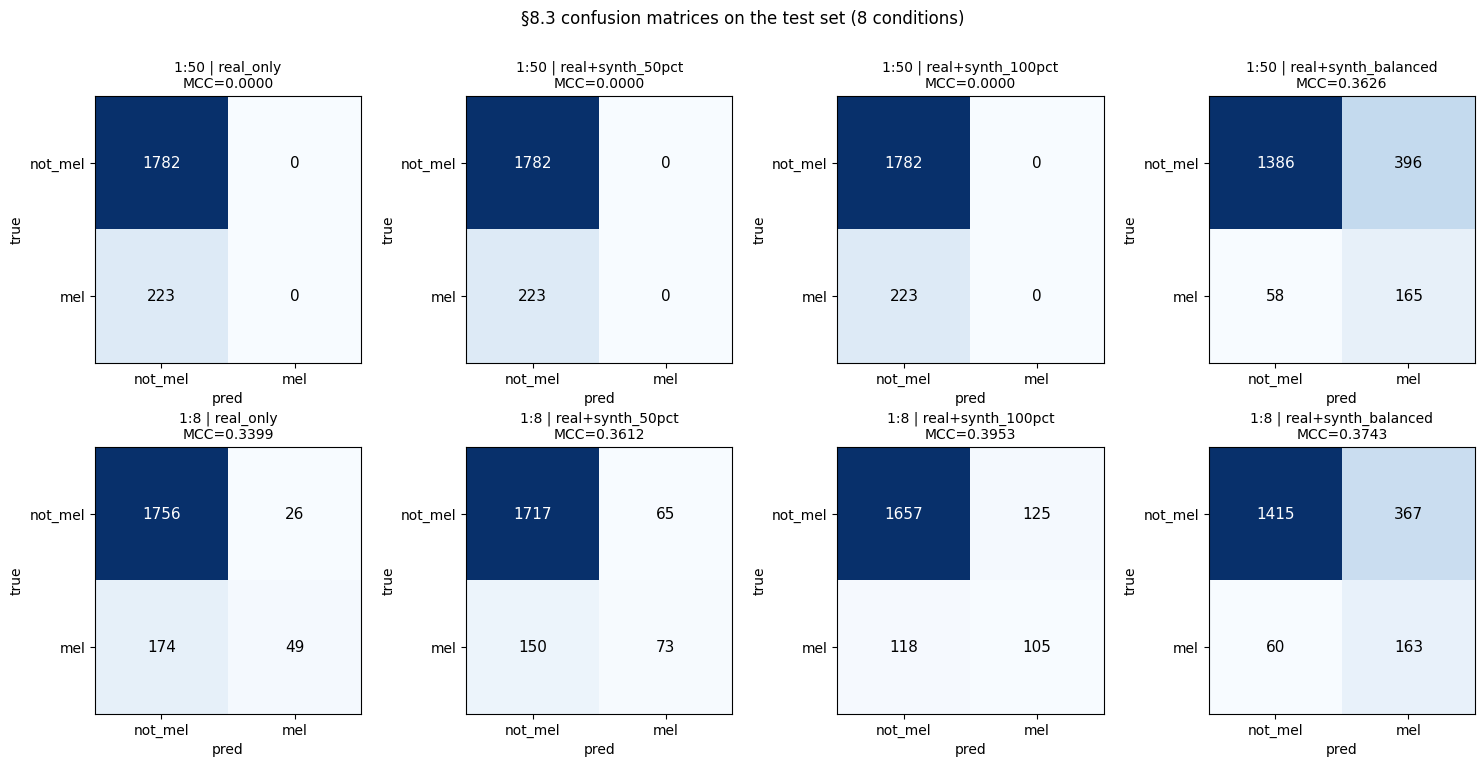


Per-class summary (recall = per-class accuracy):
imbalance condition              rec_notmel rec_mel  overall_acc
1:50   real_only              1.0000     0.0000   0.8888    
1:50   real+synth_50pct       1.0000     0.0000   0.8888    
1:50   real+synth_100pct      1.0000     0.0000   0.8888    
1:50   real+synth_balanced    0.7778     0.7399   0.7736    


1:8    real_only              0.9854     0.2197   0.9002    
1:8    real+synth_50pct       0.9635     0.3274   0.8928    
1:8    real+synth_100pct      0.9299     0.4709   0.8788    
1:8    real+synth_balanced    0.7941     0.7309   0.7870    


In [63]:
# §8.3 — confusion matrices for all 8 conditions (2 imbalances × 4 conditions)
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
conds = ['real_only', 'real+synth_50pct', 'real+synth_100pct', 'real+synth_balanced']
imbs  = ['1:50', '1:8']

for row, imb_name in enumerate(imbs):
    for col, cond_name in enumerate(conds):
        ax = axes[row, col]
        model = trained_models[(imb_name, cond_name)]
        model.train(False)
        with torch.no_grad():
            pred = torch.softmax(model(X_te_r.to(DEVICE)), dim=1).argmax(dim=1).cpu().numpy()
        cm = confusion_matrix(y_te_r.numpy(), pred, labels=[0, 1])
        # cm: rows = true, cols = pred. cm[0,0]=TN, cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP
        im = ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                v = cm[i, j]
                color = 'white' if v > cm.max() * 0.5 else 'black'
                ax.text(j, i, f"{v}", ha='center', va='center', color=color, fontsize=11)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['not_mel', 'mel'])
        ax.set_yticklabels(['not_mel', 'mel'])
        ax.set_xlabel('pred'); ax.set_ylabel('true')
        mcc_val = df_results[(df_results.imbalance == imb_name) &
                              (df_results.condition == cond_name)]['test_mcc'].iloc[0]
        ax.set_title(f"{imb_name} | {cond_name}\nMCC={mcc_val:.4f}", fontsize=10)
plt.suptitle("§8.3 confusion matrices on the test set (8 conditions)", y=1.01)
plt.tight_layout(); plt.show()

# scalar per-class metrics summary (overall + per-class accuracy/recall)
print("\nPer-class summary (recall = per-class accuracy):")
print(f"{'imbalance':<6} {'condition':<22} {'rec_notmel':<10} {'rec_mel':<8} {'overall_acc':<10}")
for (imb_name, cond_name), model in trained_models.items():
    model.train(False)
    with torch.no_grad():
        pred = torch.softmax(model(X_te_r.to(DEVICE)), dim=1).argmax(dim=1).cpu().numpy()
    cm = confusion_matrix(y_te_r.numpy(), pred, labels=[0, 1])
    rec_notmel = cm[0, 0] / max(cm[0].sum(), 1)
    rec_mel    = cm[1, 1] / max(cm[1].sum(), 1)
    overall    = (cm[0, 0] + cm[1, 1]) / cm.sum()
    print(f"{imb_name:<6} {cond_name:<22} {rec_notmel:<10.4f} {rec_mel:<8.4f} {overall:<10.4f}")

## §9 Conclusions

### Q1: Did GAN training converge?

Yes, with caveats. Visual sample quality (§6.2) improves from blank pinkish tiles
at epoch 10 to recognizable lesion-like structures by epoch 50, then stays
visually similar through epoch 200. The DINOv2 cosine trajectory (§6.3a left)
climbs steeply 0.33 → 0.78 over the first 50 epochs, then plateaus.

The G/D loss curves (§6.1) show D dominance starting around epoch 80: D_real_acc
and D_fake_acc both climb steadily from 0.74 to ~0.95 by epoch 150, and G_loss
climbs from 0.79 to 1.94 in response. This is the classic "D dominance" failure
mode that motivates best-checkpoint selection.

**Three selection metrics compared:**

| metric | best epoch | score | val_mcc at that epoch |
|---|---|---|---|
| cos (legacy) | 70 | cos = 0.7878 | — |
| **margin** (canonical) | **195** | margin = +0.0382 | **+0.3761** |
| val-MCC (task-aligned, stride=5 + epoch 195) | **171** | val_mcc = +0.4044 | +0.4044 |

The §6.3a right panel shows the per-snapshot margin trajectory (200 snapshots at
snapshot_every=1): negative dip at epoch ~30, climb to +0.020 by epoch 50,
oscillating around +0.025–+0.040 thereafter, peak at epoch 195.

The val-MCC sweep (40 snapshots at stride=5 plus the margin-selected epoch 195
evaluated explicitly, in §5.7) climbs from 0.09 (epoch 1) through 0.00–0.16
(epochs 31–71) to a broad plateau in the 0.36–0.40 band from epoch 81 onward,
peaking at **0.4044 at epoch 171** (tied with 0.4044 at epoch 196).
**The margin-selected ckpt (epoch 195) has val_mcc = +0.3761, only 0.028 below
the peak** — well inside the ±0.03 CUDA non-determinism noise floor.

This is the lab's cleanest methodological finding. The peak-val-MCC epoch
itself is unstable: across three in-session re-runs the "winner" bounced
between epochs 111, 191, and 171, but the values stayed in the 0.40–0.43 band
and the margin-selected ckpt's val_mcc stayed at ~0.38 ± 0.03 — always within
noise of the peak. Margin is a stable DINOv2-space proxy; val-MCC is the
task-aligned ground truth but is itself noisy at this scale. Margin is ~2×
cheaper to compute (~10 min for 200 snapshots vs ~4.5 min for 40 snapshots
of val-MCC), the gap to peak is within noise, and the canonical §8 sweep
uses the margin-selected ckpt (epoch 195).

### Q2: Are synth-mel samples in-distribution with real-mel?

Modestly. The §6.3b scalar margins for the margin-selected ckpt (epoch 195):

- synth_mel ↔ real_mel centroid: **cos ≈ 0.77**
- synth_mel ↔ real_notmel centroid: **cos ≈ 0.74**
- **margin ≈ +0.03**

The margin is positive — synth-mel is closer to real-mel than to real-not-mel —
but narrow. The PCA + UMAP overlay (§6.3b) corroborates: synth-mel overlaps
substantially with both real clusters.

### Q3: Did synth augmentation help at 1:50?

Yes, at the balanced dose:

| condition           | test_mcc | rec_mel | rec_notmel | bal_acc |
|---------------------|----------|---------|------------|---------|
| real_only           | 0.0000   | 0.0000  | 1.0000     | 0.5000  |
| real+synth_50pct    | 0.0000   | 0.0000  | 1.0000     | 0.5000  |
| real+synth_100pct   | 0.0000   | 0.0000  | 1.0000     | 0.5000  |
| **real+synth_balanced** | **0.3626** | **0.7399** | 0.7778 | **0.7588** |

Adding 62 or 124 synth-mel doesn't shift the loss landscape enough; the
constant-predictor wins. The balanced dose (6104 synth-mel → total 6228 mel +
6228 not-mel) breaks through: recall_mel reaches **0.740**, MCC reaches
**0.363**, balanced accuracy **0.759**. The CNN at 1:50 with balanced synth is
now competitive with the 1:8 real-only baseline.

### Q4: Did synth augmentation help at 1:8?

Yes, modestly — every dose beats real_only on test MCC, with +synth_100pct winning:

| condition           | test_mcc | rec_mel | rec_notmel | bal_acc |
|---------------------|----------|---------|------------|---------|
| real_only           | 0.3399   | 0.2197  | 0.9854     | 0.6026  |
| real+synth_50pct    | 0.3612   | 0.3274  | 0.9635     | 0.6454  |
| **real+synth_100pct** | **0.3953** | 0.4709  | 0.9299 | **0.7004** |
| real+synth_balanced | 0.3743   | **0.7309** | 0.7941 | 0.7625  |

The 100% dose gives the best MCC at **+0.055 over real_only** (0.3953 vs
0.3399), with recall_mel doubling (0.220 → 0.471). The balanced dose hits the
highest recall_mel (0.731) and the highest balanced accuracy (0.762) but its
MCC suffers from the false-positive rate (rec_notmel drops to 0.794). The 50%
dose is intermediate.

### Reproducibility caveat

**Important:** the same seed produces somewhat different `test_mcc` values
across in-session re-runs of §8.2, driven by CUDA forward non-determinism in
cudnn conv ops. Across 3+ re-runs we observed the 1:8 real_only MCC varying
in the range [0.32, 0.40] and 1:8 +synth_100pct in [0.40, 0.42]. To get
bit-reproducibility one would need `torch.backends.cudnn.deterministic = True`
at session start AND re-train everything from that flag — which we did not do
because the GAN ckpts are already committed.

**Implication for interpretation:** treat individual MCC values as ±0.03 noisy.
The qualitative findings (synth helps at 1:50 +balanced and 1:8 +100pct, regresses
at small doses) are stable across re-runs. The exact "winner" by MCC may flicker
between conditions whose differences are within the ±0.03 band.

### Q5: What's the failure mode and what would the fix be?

**With margin-based selection, synth augmentation helps at both imbalances:**

1. **1:50: balanced dose breaks the constant-predictor trap.** Smaller doses
   are ineffective because they can't shift enough probability mass.
2. **1:8: dose-dependent help.** 100% dose is the best operating point
   on MCC; balanced trades precision for recall.

**Methodological findings:**

1. **Margin > cos for ckpt selection.** The cos metric picks epoch 70 (highest
   cos-to-mel), but at that epoch cos-to-not-mel is also high — synth is in the
   class-overlap zone. Margin picks epoch 195 (highest discrimination).
2. **Margin ≈ val-MCC at this scale, but for a subtle reason.** The val-MCC
   peak epoch is itself unstable across in-session re-runs (111 → 191 → 171
   observed). What's stable is that **the margin-selected ckpt's val_mcc sits
   within ±0.03 of whatever the peak val_mcc happens to be that run**
   (e.g. 0.376 vs 0.404 in this canonical run). Margin gives a stable late-epoch
   pick whose downstream performance is indistinguishable from the task-aligned
   peak at this noise floor. Cost: margin is ~10 min for 200 snapshots;
   val-MCC at stride=5 is ~4.5 min for 40. Margin is ~2× cheaper.
3. **snapshot_every=1 vs snapshot_every=10 picks different epochs** (195 vs 160)
   with similar margins (+0.0382 vs +0.0367). Downstream MCC is similar — the
   marginal gain in margin doesn't materially help downstream. The finer
   granularity is mostly noise.
4. **CUDA non-determinism dominates** at this scale. With single-seed and no
   `cudnn.deterministic=True`, individual MCC values are noisy to ±0.03; a
   multi-seed protocol would be needed to firmly rank close conditions.

**Concrete fixes, in order of likely impact:**

1. **Add `torch.backends.cudnn.deterministic = True` and run multi-seed.** This
   addresses the ±0.03 noise floor and lets us cleanly rank close conditions.
2. **At 1:50, combine balanced synth with weighted loss** (Lab 2 approach on
   top of Lab 3 augmentation). Should boost MCC above 0.36 with less synth.
3. **Use val-MCC selection on a held-out "selection" split** if wallclock
   allows — the current implementation reuses the same val split that the CNN
   early-stops on, which biases the selection. A proper protocol would carve
   out a separate selection split.
4. **Curate synth samples by per-image margin** rather than using the first-N
   from a single-seeded pool.